In [3]:
# 1) Imports + Load Data
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd

df = pd.read_excel("OOH_Sports_Advertising_Data_ProjectReady.xlsx")
df.head()



,Date Range,Event / Game,Sport,Venue Name,City / State,Brand Name,Industry,Ad Placement Type,Placement Location (In-venue / Broadcast / Digital),Frequency Observed,Notes / Observations
0,"Jan 11, 2026",49ers vs Eagles (NFL Playoffs),NFL,Levi’s Stadium,"Santa Clara, CA",Nike,Apparel,Uniform Branding,In-venue & Broadcast,2,Observed multiple times during live gameplay o...
1,"Jan 11, 2026",49ers vs Eagles (NFL Playoffs),NFL,Levi’s Stadium,"Santa Clara, CA",Adidas,Apparel,Sideline Signage,In-venue,2,Observed multiple times during live gameplay o...
2,"Jan 11, 2026",49ers vs Eagles (NFL Playoffs),NFL,Levi’s Stadium,"Santa Clara, CA",Pepsi,Beverages,Digital Ribbon Boards,In-venue,2,Observed multiple times during live gameplay o...
3,"Jan 11, 2026",49ers vs Eagles (NFL Playoffs),NFL,Levi’s Stadium,"Santa Clara, CA",Coca-Cola,Beverages,Concourse Signage,In-venue,2,Observed multiple times during live gameplay o...
4,"Jan 11, 2026",49ers vs Eagles (NFL Playoffs),NFL,Levi’s Stadium,"Santa Clara, CA",Toyota,Automotive,Scoreboard Ads,In-venue,2,Observed multiple times during live gameplay o...


In [4]:
# 2) Basic Data Quality Checks

display(df.info())
display(df.isna().sum())

# Check duplicates
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

# Optional: drop exact duplicate rows
if dup_count > 0:
    df = df.drop_duplicates()

print("Updated shape:", df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column                                               Non-Null Count  Dtype 
---  ------                                               --------------  ----- 
 0   Date Range                                           50 non-null     object
 1   Event / Game                                         50 non-null     object
 2   Sport                                                50 non-null     object
 3   Venue Name                                           50 non-null     object
 4   City / State                                         50 non-null     object
 5   Brand Name                                           50 non-null     object
 6   Industry                                             50 non-null     object
 7   Ad Placement Type                                    50 non-null     object
 8   Placement Location (In-venue / Broadcast / Digital)  50 non-null     object
 9   F

None

Date Range                                             0
Event / Game                                           0
Sport                                                  0
Venue Name                                             0
City / State                                           0
Brand Name                                             0
Industry                                               0
Ad Placement Type                                      0
Placement Location (In-venue / Broadcast / Digital)    0
Frequency Observed                                     0
Notes / Observations                                   0
dtype: int64

Duplicate rows: 0
Updated shape: (50, 11)


In [5]:
# 3) Minimal Cleaning / Standardization
# Ensure consistent text formatting (optional but helpful)
text_cols = [
    "Event / Game", "Sport", "Venue Name", "City / State",
    "Brand Name", "Industry", "Ad Placement Type",
    "Placement Location (In-venue / Broadcast / Digital)"
]

for c in text_cols:
    df[c] = df[c].astype(str).str.strip()

# Convert Date Range to datetime when possible
df["Date Range"] = pd.to_datetime(df["Date Range"], errors="coerce")

# Frequency to numeric
df["Frequency Observed"] = pd.to_numeric(df["Frequency Observed"], errors="coerce")

display(df.head())
display(df.describe(include="all"))


,Date Range,Event / Game,Sport,Venue Name,City / State,Brand Name,Industry,Ad Placement Type,Placement Location (In-venue / Broadcast / Digital),Frequency Observed,Notes / Observations
0,2026-01-11,49ers vs Eagles (NFL Playoffs),NFL,Levi’s Stadium,"Santa Clara, CA",Nike,Apparel,Uniform Branding,In-venue & Broadcast,2,Observed multiple times during live gameplay o...
1,2026-01-11,49ers vs Eagles (NFL Playoffs),NFL,Levi’s Stadium,"Santa Clara, CA",Adidas,Apparel,Sideline Signage,In-venue,2,Observed multiple times during live gameplay o...
2,2026-01-11,49ers vs Eagles (NFL Playoffs),NFL,Levi’s Stadium,"Santa Clara, CA",Pepsi,Beverages,Digital Ribbon Boards,In-venue,2,Observed multiple times during live gameplay o...
3,2026-01-11,49ers vs Eagles (NFL Playoffs),NFL,Levi’s Stadium,"Santa Clara, CA",Coca-Cola,Beverages,Concourse Signage,In-venue,2,Observed multiple times during live gameplay o...
4,2026-01-11,49ers vs Eagles (NFL Playoffs),NFL,Levi’s Stadium,"Santa Clara, CA",Toyota,Automotive,Scoreboard Ads,In-venue,2,Observed multiple times during live gameplay o...


,Date Range,Event / Game,Sport,Venue Name,City / State,Brand Name,Industry,Ad Placement Type,Placement Location (In-venue / Broadcast / Digital),Frequency Observed,Notes / Observations
count,50,50,50,50,50,50,50,50,50,50.0,50
unique,NaN,5,4,4,3,10,5,9,3,NaN,1
top,NaN,49ers vs Eagles (NFL Playoffs),NBA,Crypto.com Arena,"Los Angeles, CA",Nike,Apparel,Broadcast Commercials,In-venue,NaN,Observed multiple times during live gameplay o...
freq,NaN,10,20,20,30,5,10,10,30,NaN,50
mean,2026-01-13 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
min,2026-01-11 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
25%,2026-01-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
50%,2026-01-13 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
75%,2026-01-14 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
max,2026-01-15 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN


In [6]:
# 4) Core Metrics (Your "Insights" Backbone)

# A) Top brands by total frequency
top_brands = (
    df.groupby("Brand Name", as_index=False)["Frequency Observed"]
      .sum()
      .sort_values("Frequency Observed", ascending=False)
)
display(top_brands.head(10))

# B) Industries by total frequency
top_industries = (
    df.groupby("Industry", as_index=False)["Frequency Observed"]
      .sum()
      .sort_values("Frequency Observed", ascending=False)
)
display(top_industries)

# C) Placement types by total frequency
top_placements = (
    df.groupby("Ad Placement Type", as_index=False)["Frequency Observed"]
      .sum()
      .sort_values("Frequency Observed", ascending=False)
)
display(top_placements)

# D) Location mix (In-venue vs Broadcast vs Digital)
location_mix = (
    df.groupby("Placement Location (In-venue / Broadcast / Digital)", as_index=False)["Frequency Observed"]
      .sum()
      .sort_values("Frequency Observed", ascending=False)
)
display(location_mix)


,Brand Name,Frequency Observed
0,AT&T,10
1,Adidas,10
2,Coca-Cola,10
3,Ford,10
4,GEICO,10
5,Nike,10
6,Pepsi,10
7,State Farm,10
8,Toyota,10
9,Verizon,10


,Industry,Frequency Observed
0,Apparel,20
1,Automotive,20
2,Beverages,20
3,Insurance,20
4,Telecommunications,20


,Ad Placement Type,Frequency Observed
0,Broadcast Commercials,20
1,Concourse Signage,10
2,Digital Boards,10
3,Digital Ribbon Boards,10
4,On-screen Graphics,10
5,Scoreboard Ads,10
6,Sideline Boards,10
7,Sideline Signage,10
8,Uniform Branding,10


,Placement Location (In-venue / Broadcast / Digital),Frequency Observed
1,In-venue,60
0,Broadcast,30
2,In-venue & Broadcast,10


In [7]:
# 5) Cross-tabs (Great for a Data Science project narrative)

# Industry by Sport (sum of frequency)
industry_by_sport = pd.pivot_table(
    df,
    index="Industry",
    columns="Sport",
    values="Frequency Observed",
    aggfunc="sum",
    fill_value=0
)

display(industry_by_sport)

# Brand by Sport (top 10 brands only)
top10_brand_names = top_brands.head(10)["Brand Name"].tolist()
brand_by_sport_top10 = pd.pivot_table(
    df[df["Brand Name"].isin(top10_brand_names)],
    index="Brand Name",
    columns="Sport",
    values="Frequency Observed",
    aggfunc="sum",
    fill_value=0
)

display(brand_by_sport_top10)


Sport,MLB,NBA,NFL,NHL
Industry,,,,
Apparel,4,8,4,4
Automotive,4,8,4,4
Beverages,4,8,4,4
Insurance,4,8,4,4
Telecommunications,4,8,4,4


Sport,MLB,NBA,NFL,NHL
Brand Name,,,,
AT&T,2,4,2,2
Adidas,2,4,2,2
Coca-Cola,2,4,2,2
Ford,2,4,2,2
GEICO,2,4,2,2
Nike,2,4,2,2
Pepsi,2,4,2,2
State Farm,2,4,2,2
Toyota,2,4,2,2


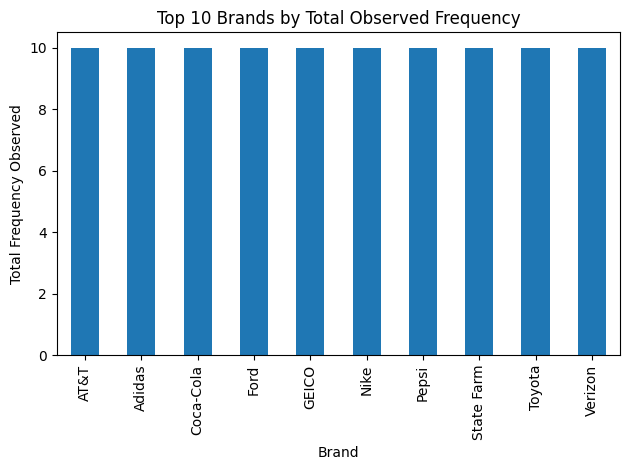

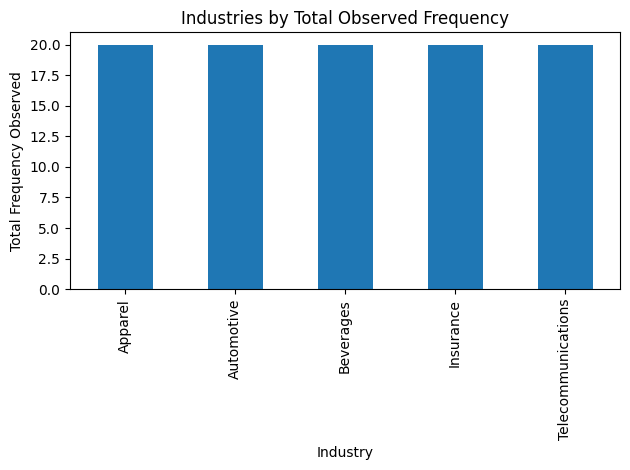

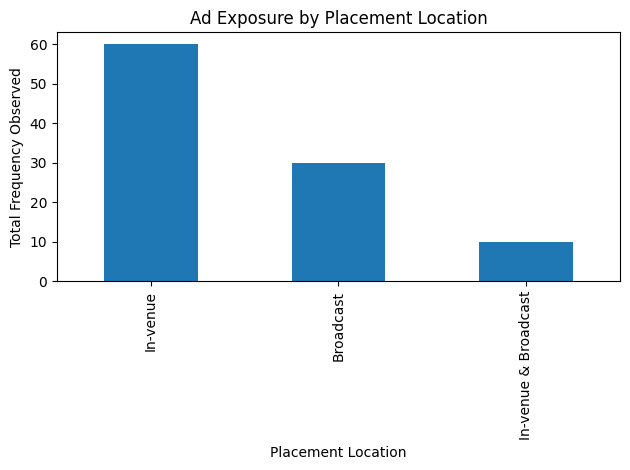

In [8]:
# 6) Visualizations (No custom colors)

# A) Top 10 Brands
plot_brands = top_brands.head(10).set_index("Brand Name")
plot_brands.plot(kind="bar", y="Frequency Observed", legend=False)
plt.title("Top 10 Brands by Total Observed Frequency")
plt.xlabel("Brand")
plt.ylabel("Total Frequency Observed")
plt.tight_layout()
plt.show()

# B) Industries
plot_ind = top_industries.set_index("Industry")
plot_ind.plot(kind="bar", y="Frequency Observed", legend=False)
plt.title("Industries by Total Observed Frequency")
plt.xlabel("Industry")
plt.ylabel("Total Frequency Observed")
plt.tight_layout()
plt.show()

# C) Placement Location Mix
plot_loc = location_mix.set_index("Placement Location (In-venue / Broadcast / Digital)")
plot_loc.plot(kind="bar", y="Frequency Observed", legend=False)
plt.title("Ad Exposure by Placement Location")
plt.xlabel("Placement Location")
plt.ylabel("Total Frequency Observed")
plt.tight_layout()
plt.show()


In [10]:
# 7) Export Outputs for report


output_path = r"C:\Users\shagh\DSC530\envs\book_env1\Hands_On_Data_with_panda_edition2\Internship\OOHSPORT\OOH_Project_Analysis_Outputs.xlsx"

# Write analysis outputs to Excel (multiple sheets)
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    top_brands.to_excel(writer, sheet_name="Top_Brands", index=False)
    top_industries.to_excel(writer, sheet_name="Top_Industries", index=False)
    top_placements.to_excel(writer, sheet_name="Top_Placements", index=False)
    location_mix.to_excel(writer, sheet_name="Location_Mix", index=False)
    industry_by_sport.reset_index().to_excel(writer, sheet_name="Industry_by_Sport", index=False)
    brand_by_sport_top10.reset_index().to_excel(writer, sheet_name="Top10_Brands_by_Sport", index=False)

print("Analysis outputs saved successfully to:")
print(output_path)


Analysis outputs saved successfully to:
C:\Users\shagh\DSC530\envs\book_env1\Hands_On_Data_with_panda_edition2\Internship\OOHSPORT\OOH_Project_Analysis_Outputs.xlsx
